In [1]:
# These modules are required for this example.
import numpy as np
import astropy.units as u
from dysh.spectra import tsys_weight
from dysh.spectra import average_spectra
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.log import init_logging

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
filename = dysh_data(test="getps")

16:09:24.343 I Resolving test=getps -> AGBT05B_047_01/AGBT05B_047_01.raw.acs/


In [4]:
sdf = GBTFITSLoad(filename)
sdf.summary()

16:09:24.446 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,198.3431,18.6427
52,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,198.9306,18.7872
53,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,199.3305,18.3561
54,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,199.9157,18.4927
55,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,200.3042,18.0575
56,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,200.8906,18.1860
57,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,202.3275,17.3853
58,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,202.9192,17.4949


In [5]:
pssb = sdf.getps(object='NGC5291', ifnum=0, plnum=1, fdnum=0)
print(f"Number of scans: {len(pssb)}, Number of integrations per scan: {[k.nint for k in pssb]}")
print(f"Scan weights: {pssb.weights}")

Number of scans: 4, Number of integrations per scan: [11, 11, 11, 11]
Scan weights: [array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]), array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])]


In [6]:
pssb.tsys_weight

array([array([20.02238592, 19.23775753, 19.89469281, 19.13748516, 19.43619207,
              19.24989036, 19.94781504, 19.81766121, 19.90398672, 19.86791497,
              19.1754635 ])                                                   ,
       array([18.94476267, 19.78439063, 19.85434244, 19.90054628, 19.95968097,
              19.08878802, 18.97575899, 18.5760123 , 19.76114768, 19.71441725,
              19.70968407])                                                   ,
       array([18.77161334, 19.62257845, 19.70200273, 19.68613794, 19.65882906,
              19.85660591, 19.57284449, 19.60902436, 18.74157248, 18.6538321 ,
              18.75593527])                                                   ,
       array([18.44256036, 18.36839774, 18.34613799, 18.39603826, 17.95338427,
              19.04965151, 19.09771163, 19.18475276, 19.09809603, 19.09126971,
              18.34217249])                                                   ],
      dtype=object)

16:09:27.937 I 1370000000.0 Hz is below the minimum spectral axis 1374818364.0 Hz. Replacing.


16:09:27.938 I 1430000000.0 Hz is above the maximum spectral axis 1424816838.1210938 Hz. Replacing.


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


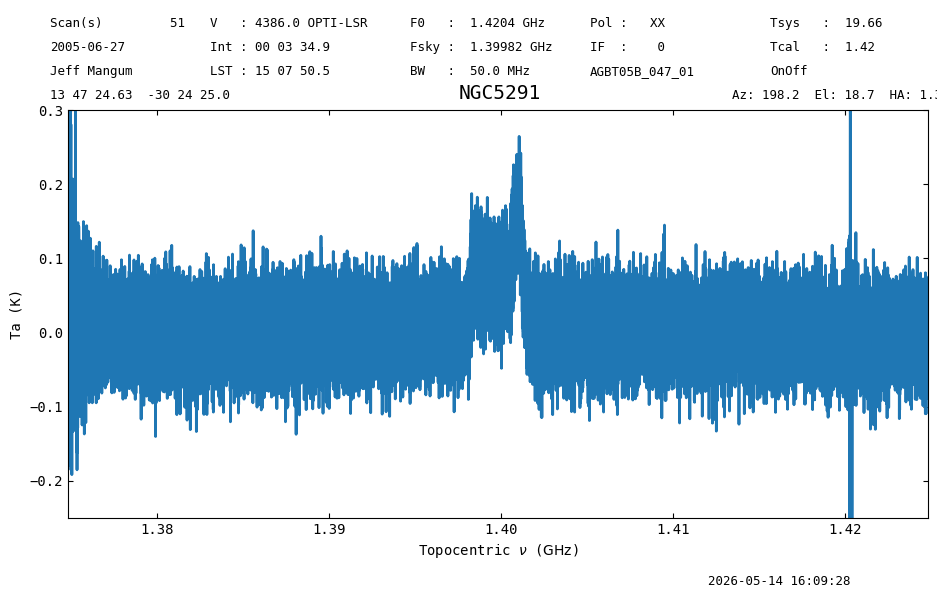

final weights=[847.9619254640448 847.9619254640448 847.9619254640448 ...
 847.9619254640448 847.9619254640448 847.9619254640448]


{'mean': <Quantity 0.00493475 K>,
 'median': <Quantity 0.00348282 K>,
 'rms': <Quantity 0.05926608 K>,
 'min': <Quantity -1.74795385 K>,
 'max': <Quantity 0.76657302 K>,
 'npt': 32768,
 'nan': np.int64(0)}

In [7]:
ta1 = pssb.timeaverage()  # default is weights='tsys'

# Define regions to be excluded from the baseline fit.
exclude_regions = [(1.37*u.GHz,1.38*u.GHz),
                   (1.395*u.GHz,1.405*u.GHz),
                   (1.42*u.GHz,1.43*u.GHz)]

# Fit an order 1 polynomial excluding the ranges defined above and subtract it (remove=True).
ta1.baseline(degree=1, remove=True, exclude=exclude_regions)

# Plot the result.
ta1.plot(ymin=-0.25, ymax=0.3)

# Print final weights and statistics.
print(f"final weights={ta1.weights}")
ta1.stats()  # rms 0.05926608 K

16:09:29.555 I 1370000000.0 Hz is below the minimum spectral axis 1374818364.0 Hz. Replacing.


16:09:29.555 I 1430000000.0 Hz is above the maximum spectral axis 1424816838.1210938 Hz. Replacing.


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


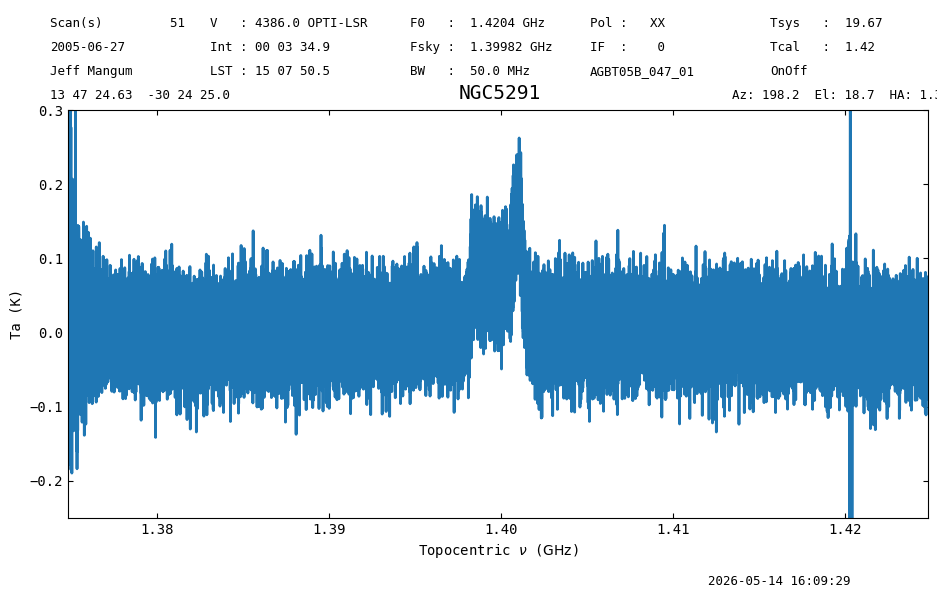

final weights=[4.0 4.0 4.0 ... 4.0 4.0 4.0]


{'mean': <Quantity 0.00493513 K>,
 'median': <Quantity 0.00344473 K>,
 'rms': <Quantity 0.05928395 K>,
 'min': <Quantity -1.74943676 K>,
 'max': <Quantity 0.76626611 K>,
 'npt': 32768,
 'nan': np.int64(0)}

In [8]:
ta2 = pssb.timeaverage(weights=None)  
ta2.baseline(degree=1, remove=True, exclude=exclude_regions)
ta2.plot(ymin=-0.25, ymax=0.3)
print(f"final weights={ta2.weights}")
ta2.stats() # rms 0.05928395 K

16:09:31.027 I 1370000000.0 Hz is below the minimum spectral axis 1374818364.0 Hz. Replacing.


16:09:31.028 I 1430000000.0 Hz is above the maximum spectral axis 1424816838.1210938 Hz. Replacing.


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


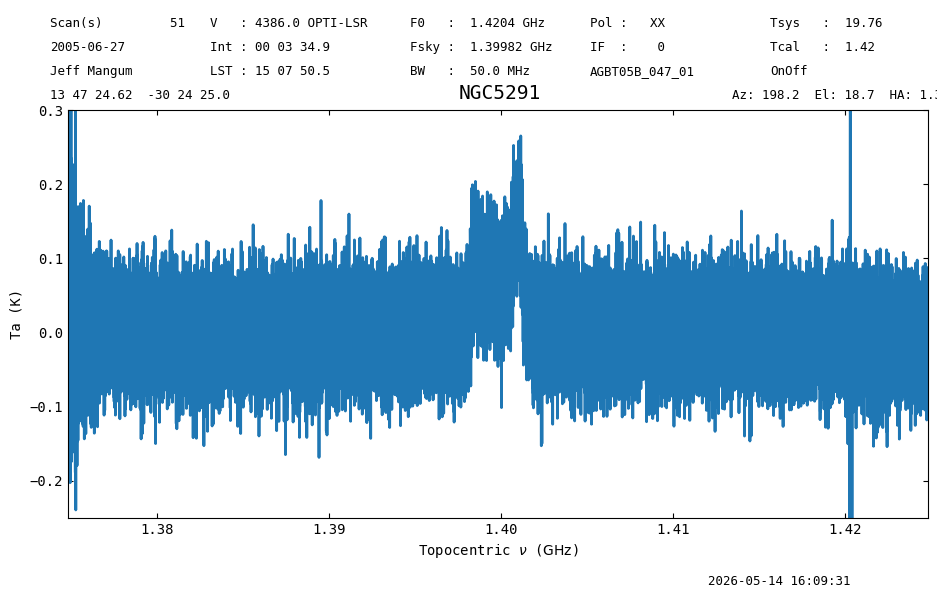

final weights=[990.0 990.0 990.0 ... 990.0 990.0 990.0]


In [9]:
w = np.arange(1, pssb.nint+1, dtype=float)
ta3a = pssb.timeaverage(weights=w)
ta3a.baseline(degree=1, remove=True, exclude=exclude_regions)
ta3a.plot(ymin=-0.25, ymax=0.3)
print(f"final weights={ta3a.weights}")

In [10]:
np.random.seed(123)  # make sure we have a fixed seed
tsys = 30 + np.random.rand(pssb.nint, pssb.nchan)*15.0  # Fake system temperature array in the 30-45K range.
# The mean exposure and channel width.
dt = np.mean(np.mean(pssb.exposure))
df = np.mean(np.mean(pssb.delta_freq))

# Compute new weights using the inverse variance as given by the radiometer equation.
w = tsys_weight(dt, df, tsys)
print(f"{tsys=}")
print(f"Weights array shape: {w.shape}")

tsys=array([[40.44703778, 34.29209002, 33.4027718 , ..., 38.71791603,
        35.28713315, 40.87063212],
       [38.05088391, 33.34662369, 42.20490842, ..., 41.80063624,
        38.89300609, 40.57733459],
       [35.43088049, 39.82836535, 33.14689888, ..., 33.44782766,
        40.81104733, 34.50116723],
       ...,
       [44.27286605, 40.55077356, 32.97672831, ..., 40.44991244,
        31.97284355, 39.87806732],
       [43.54054032, 37.95174176, 36.0192332 , ..., 30.24616871,
        32.32690178, 40.55712875],
       [31.4013107 , 36.35880619, 38.0259688 , ..., 34.22566874,
        42.53679606, 40.73033967]], shape=(44, 32768))
Weights array shape: (44, 32768)


16:09:32.763 I 1370000000.0 Hz is below the minimum spectral axis 1374818364.0 Hz. Replacing.


16:09:32.764 I 1430000000.0 Hz is above the maximum spectral axis 1424816838.1210938 Hz. Replacing.


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


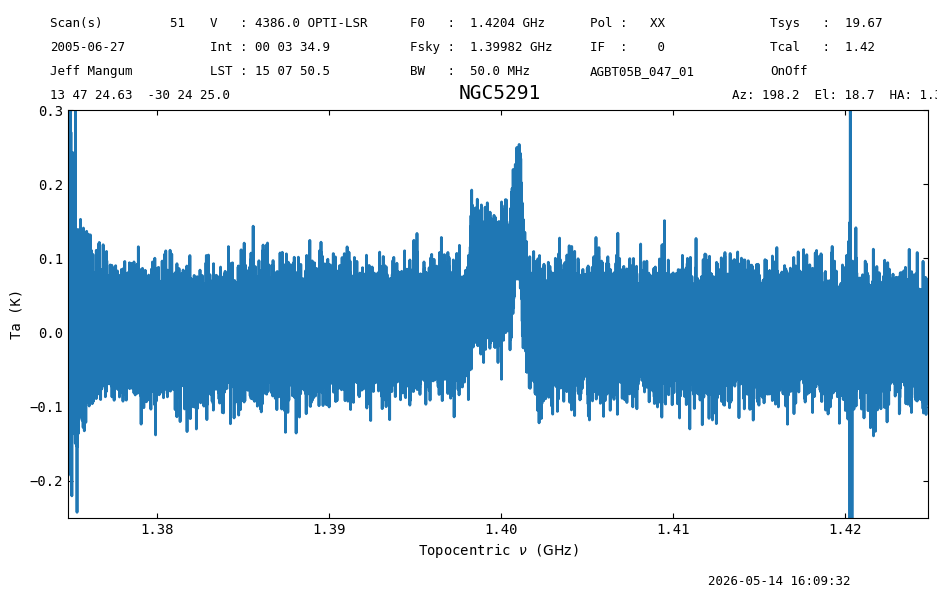

final weights=[243.43698152112933 245.3675937036399 237.113209395157 ...
 242.4000731446227 249.68128171631173 237.80401320732614]


In [11]:
ta3b = pssb.timeaverage(weights=w)
ta3b.baseline(degree=1, remove=True, exclude=exclude_regions)
ta3b.plot(ymin=-0.25, ymax=0.3)
print(f"final weights={ta3b.weights}")

In [12]:
print(pssb[0].weights.shape)
print(f"Are the Scan weights the same as those we defined? {np.all(w[0:11] == pssb[0].weights)}")

(11, 32768)
Are the Scan weights the same as those we defined? True


In [13]:
sp = average_spectra([ta1, ta2, ta3a, ta3b], weights='spectral')

# but this is the same:
# sp = ta1.average([ ta2, ta3a, ta3b], weights='spectral')

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


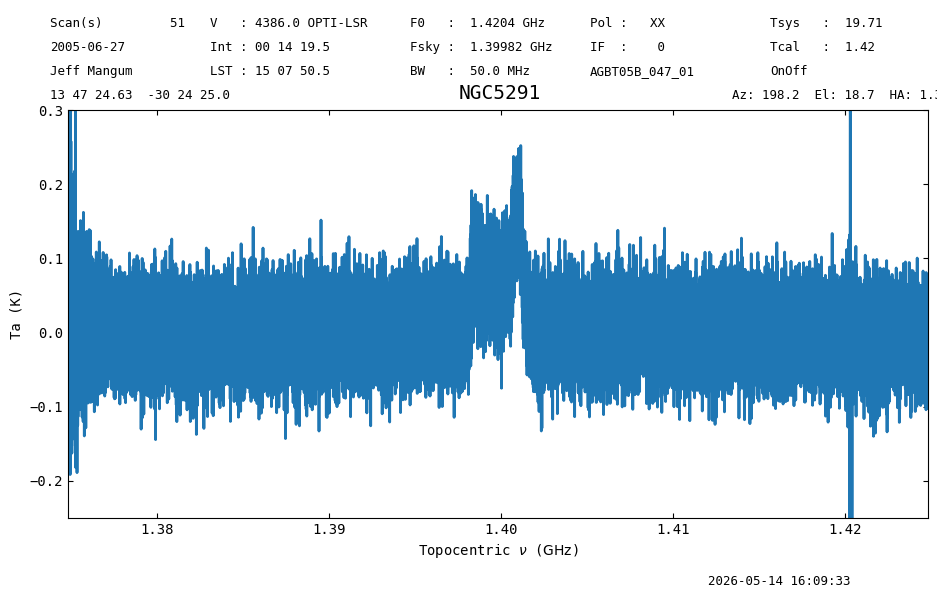

final weights=[2085.398906985174 2087.329519167685 2079.0751348592016 ...
 2084.3619986086674 2091.6432071803565 2079.765938671371]


In [14]:
sp.plot(ymin=-0.25, ymax=0.3)
print(f"final weights={sp.weights}")

In [15]:
sp.check_stats(0.06025871 * u.K)

16:09:34.365 I rms is OK 
